In [20]:
import pathlib

_REPO = pathlib.Path("..").resolve()

def raw(subdir):
    return _REPO / "data" / "raw" / subdir

PATENTS_FRAC      = "pf_inv_ctry_year_frac.csv"

ANALYSIS_START, ANALYSIS_END = 1960, 2023


import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / "src"))

import pandas as pd
import numpy as np
from sanctions_innovations.patents import load_and_prepare_patents

patents_df, missing_codes = load_and_prepare_patents(
    str(raw("patents") / PATENTS_FRAC),
)
print(
    f'Following {len(missing_codes)} country-codes have no iso3 from patstat and have '
    f'{0.0} patents:\n {missing_codes}'
)


Following 86 country-codes have no iso3 from patstat and have 0.0 patents:
 ['SJ', 'PR', 'VI', 'ZR', 'UM', 'GP', 'CX', 'RE', 'KA', 'PC', 'NC', 'PF', 'UK', 'XK', 'UN', 'GF', 'AS', 'CC', 'TY', 'IO', '97', 'NJ', 'ZJ', 'OH', 'WF', 'CT', 'YS', 'SF', 'PS', 'PN', 'TK', 'UC', 'TP', 'JA', 'MQ', 'UD', 'U', 'NY', 'MI', 'NF', 'RF', 'PI', 'WA', 'RH', 'GU', 'KT', 'JS', 'ON', 'XX', 'FL', 'HW', 'TF', 'AX', 'KS', 'LN', 'UX', 'SP', 'SW', 'TX', 'PO', 'UT', 'NX', 'ZZ', 'FM', 'VZ', 'WV', 'BC', 'NH', 'PM', 'AB', 'XH', 'FA', 'RJ', 'WE', 'TS', 'XA', 'ZH', 'XP', 'S', 'OR', 'RI', 'BL', 'FX', 'UR', 'IA', 'NV']


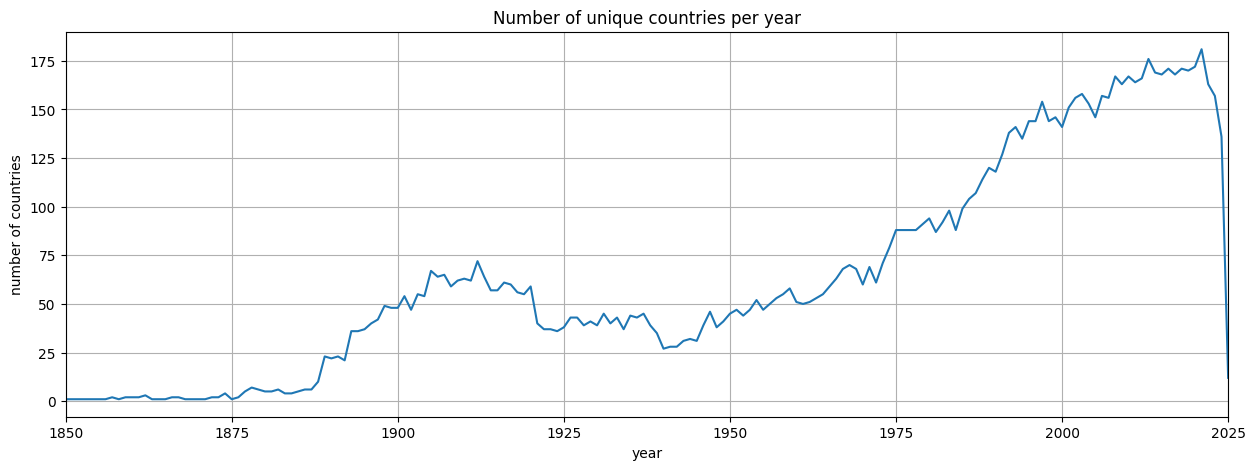

In [21]:
ax = patents_df.groupby('priority_year').ctry_code.nunique().plot(
    title='Number of unique countries per year', label='unique countries', figsize=(15,5), grid=True
)
ax.set_xlabel('year')
ax.set_ylabel('number of countries')
ax.set_xlim(1850, 2025)
ax.set_xticks(range(1850, 2026, 25))

In [22]:
patents_df.reset_index(inplace=True)

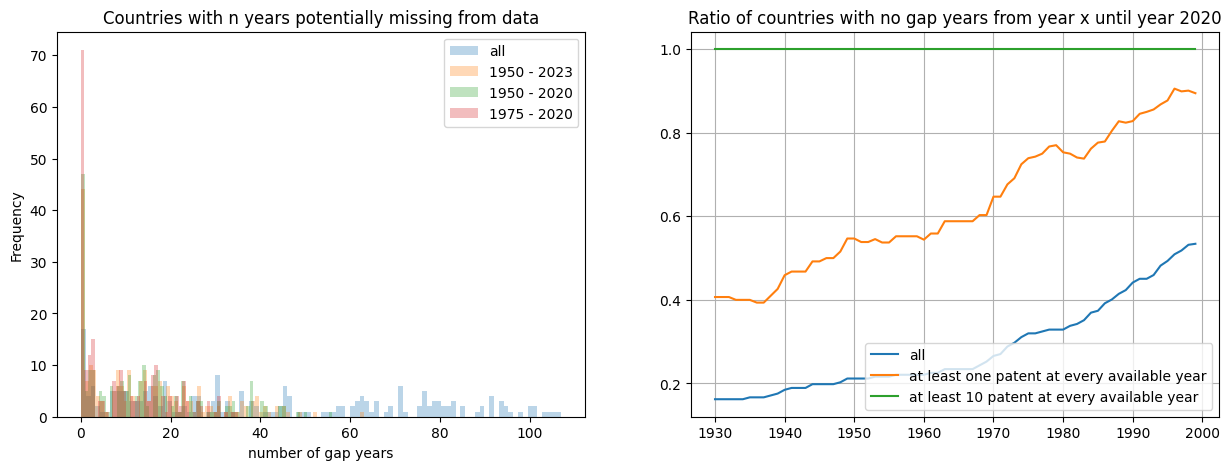

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(15,5))

patents_df.groupby('iso3').priority_year.agg(['count','min','max']).assign(
    n_gaps = lambda x: x['max'] - x['min'] - x['count'] + 1
    ).n_gaps.plot.hist(bins=100, alpha=0.3, label='all', ax=ax[0])


for from_year, to_year in [
    (1950,2023), 
    (1950,2020),
    (1975,2020),
    ]:
    patents_df[lambda x: x.priority_year.between(from_year, to_year)].groupby('iso3').priority_year.agg(['count','min','max']).assign(
        n_gaps = lambda x: x['max'] - x['min'] - x['count'] + 1
    ).n_gaps.plot.hist(bins=to_year-from_year, title='Countries with n years potentially missing from data', xlabel='number of gap years', alpha=0.3, label=f'{from_year} - {to_year}', ax=ax[0])

ax[0].legend()

min_patents = 10

temp = pd.DataFrame.from_dict(
    {
        from_year: patents_df[lambda x: x.priority_year.between(from_year, 2020)].groupby('iso3').agg(
            {'priority_year':['count','min','max'], 'frac_classical_inv':['count','min','max', 'median']}
            ).assign(
                n_gaps = lambda x: x.priority_year['max'] - x.priority_year['min'] - x.priority_year['count'] + 1,
                no_gap = lambda x: x.n_gaps==0,
                no_gap_given_one_patent = lambda x: x.no_gap.where(x.frac_classical_inv['min']>=1),
                no_gap_given_min_patents = lambda x: x.no_gap.where(x.frac_classical_inv['min']>=min_patents),
                )[['no_gap', 'no_gap_given_one_patent', 'no_gap_given_min_patents']].mean() for from_year in range(1930,2000)
        }, orient='index')

temp['no_gap'].plot(grid=True, title='Ratio of countries with no gap years from year x until year 2020', ax=ax[1], label='all')
temp['no_gap_given_one_patent'].plot(grid=True, title='Ratio of countries with no gap years from year x until year 2020', ax=ax[1], label=f'at least one patent at every available year')
temp['no_gap_given_min_patents'].plot(grid=True, title='Ratio of countries with no gap years from year x until year 2020', ax=ax[1], label=f'at least {min_patents} patent at every available year')
ax[1].legend()

Example of country with a low "min" patent on every available year (AIA). We can see there is data for 1983 and 1986 but not for 1984,1985. But since the patent numbers for this country are small, it is reasonable to impute the missing years with 0. 

#### Filling in missing gaps and clip our data from 1960 till 2023

In [24]:
# patents_df = patents_df.reset_index()
patents_df = patents_df[lambda x: x.priority_year.between(ANALYSIS_START, ANALYSIS_END)].set_index(['iso3', 'priority_year'])

In [25]:
viable_years = patents_df[lambda x: x.index.get_level_values(1).isin(range(ANALYSIS_START, ANALYSIS_END))].groupby(level='iso3').frac_classical_inv.count()
print(f'{len(viable_years)} countries that have in total {viable_years.sum()} years with frac_classical_inv > 0')

223 countries that have in total 7543 years with frac_classical_inv > 0


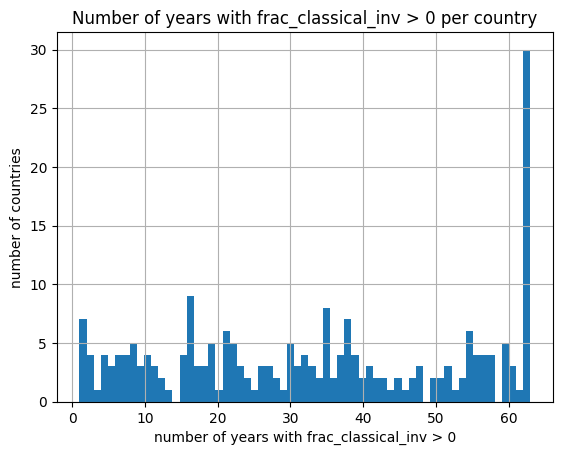

In [26]:
viable_years.plot.hist(
    title='Number of years with frac_classical_inv > 0 per country', bins=63
    )
plt.xlabel('number of years with frac_classical_inv > 0')
plt.ylabel('number of countries')
plt.grid()

In [27]:

# ── Annual totals: sum frac_classical_inv across all ctry_codes per (iso3, year) ──
# (Some iso3s map to multiple ctry_codes, so the index may have duplicate (iso3, year) entries)
annual_totals = (
    patents_df
    .groupby(level=['iso3', 'priority_year'])['frac_classical_inv']
    .sum()
)

annual_totals_window = annual_totals[
    annual_totals.index.get_level_values('priority_year').isin(range(ANALYSIS_START, ANALYSIS_END + 1))
]
country_min_annual = annual_totals_window.groupby(level='iso3').min()

observed_years = (
    patents_df.index.to_frame(index=False)
    .drop_duplicates()
    .groupby('iso3')['priority_year']
    .agg(['count', 'min', 'max'])
    .assign(gap_years=lambda x: (x['max'] - x['min'] + 1 - x['count']).clip(lower=0))
)

print(f"Min annual patents computed over {ANALYSIS_START}–{ANALYSIS_END} window\n")
print(f"{'Threshold':>10}  {'Countries below':>16}  {'w/ internal gaps':>17}  {'Total gap-years':>16}")
print("-" * 65)
for thresh in [5, 10, 20, 50]:
    below       = country_min_annual[country_min_annual < thresh].index
    gs          = observed_years.loc[observed_years.index.isin(below)]
    n_with_gaps = (gs['gap_years'] > 0).sum()
    total_gaps  = gs['gap_years'].sum()
    print(f"{thresh:>10}  {len(below):>16,}  {n_with_gaps:>17,}  {total_gaps:>16,}")

# ── Threshold-based zero imputation (min_patents = 10) ────────────────────────
min_patents = 10

low_patent_countries  = country_min_annual[country_min_annual <  min_patents].index
high_patent_countries = country_min_annual[country_min_annual >= min_patents].index

# ── Low-patent countries: fill all internal gaps with zero (original behaviour)
def _full_year_range(grp):
    yrs = grp.index.get_level_values('priority_year')
    return pd.Index(range(yrs.min(), yrs.max() + 1), name='priority_year')

low_index_tuples = [
    (iso3, yr)
    for iso3 in low_patent_countries
    if iso3 in patents_df.index.get_level_values('iso3')
    for yr in _full_year_range(patents_df.loc[[iso3]])
]

low_df = (
    patents_df
    .loc[patents_df.index.get_level_values('iso3').isin(low_patent_countries)]
    .reindex(pd.MultiIndex.from_tuples(low_index_tuples, names=['iso3', 'priority_year']))
)


Min annual patents computed over 1960–2023 window

 Threshold   Countries below   w/ internal gaps   Total gap-years
-----------------------------------------------------------------
         5               198                177             2,730
        10               201                177             2,730
        20               202                177             2,730
        50               207                177             2,730


In [28]:
print(f'Imputing zeros for low-patent countries with gaps {low_df['frac_classical_inv'].isna().sum()} missing rows (after reindexing)')

low_df['frac_classical_inv'] = low_df['frac_classical_inv'].fillna(0)

# ── High-patent countries: keep only observed years, no gap-filling
high_df = (
    patents_df
    .loc[patents_df.index.get_level_values('iso3').isin(high_patent_countries)]
    .copy()
)

# ── Recombine
patents_df = pd.concat([low_df, high_df]).sort_index()

print(f"\nThreshold = {min_patents}  (min annual patents in {ANALYSIS_START}–{ANALYSIS_END})")
print(f"  Low-patent  countries (zero-imputed): {len(low_patent_countries):,}")
print(f"  High-patent countries (no gap-fill):  {len(high_patent_countries):,}")
print(f"  High-patent country list: {sorted(high_patent_countries.tolist())}")
print(f"  Final patents_df rows: {len(patents_df):,}")

Imputing zeros for low-patent countries with gaps 2730 missing rows (after reindexing)

Threshold = 10  (min annual patents in 1960–2023)
  Low-patent  countries (zero-imputed): 201
  High-patent countries (no gap-fill):  22
  High-patent country list: ['AUS', 'AUT', 'BEL', 'BRA', 'CAN', 'CHE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'HUN', 'ITA', 'JPN', 'LIE', 'LVA', 'NLD', 'NOR', 'SWE', 'USA']
  Final patents_df rows: 10,431


<Axes: title={'center': 'Remaining countries with x missing years'}, xlabel='x', ylabel='Frequency'>

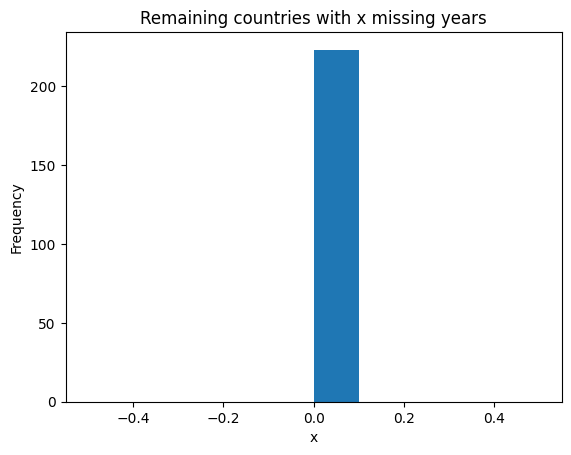

In [29]:
patents_df.reset_index().groupby('iso3').priority_year.agg(['count','min','max']).assign(
    n_gaps = lambda x: (x['max'] - x['min'] - x['count'] + 1).astype(int)
).n_gaps.plot.hist(title='Remaining countries with x missing years', xlabel='x')